In [4]:
import numpy as np
from matplotlib import pyplot as plt
import h5py
from pathlib import Path

In [6]:
notebook_dir = Path().resolve().parent.parent

# Create the 'plots' directory if it doesn't exist
path_to_plots_dir = notebook_dir / "plots"
path_to_plots_dir.mkdir(exist_ok=True)

# where output data is stored
path_to_output_dir = notebook_dir / "output"

In [2]:
label_size = 24

tick_size = 20
legend_size = 20

lw = 1.5

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]
plt.rcParams["axes.linewidth"] = 0.8

In [87]:
def compute_L2_and_next_moment_abs_error(filename, rel_moment_err, constraint_error=1e-4):
    with h5py.File(filename, "r") as f:
        
        keys = list(f.keys())
        mo_next = [x[11:] for x in keys if x.startswith("ref_M_test_")]
        mo_constraint = [x[17:] for x in keys if x.startswith("ref_M_constraint_")]
        sparsity_degree = f["sparsity_degree"][:]

        total_moment_sum_constraint = sum([abs(float(np.asarray(f[f"ref_M_constraint_{x}"]))) for x in mo_constraint])
        
        l1_constraint_moment_errors = [sum([abs(f[f"predicted_M_{x}"][:][i] - f[f"ref_M_constraint_{x}"]) for x in mo_constraint])
                                       for i in range(len(sparsity_degree))]

        if max(l1_constraint_moment_errors)/total_moment_sum_constraint > constraint_error:
            raise Exception(f"Constraints not fulfilled, error: {l1_constraint_moment_errors/total_moment_sum_constraint}")
        
        print(max(l1_constraint_moment_errors)/total_moment_sum_constraint)
        l1_moment_errors = [sum([abs(f[f"predicted_M_{x}"][:][i] - f[f"ref_M_test_{x}"]) for x in mo_next])
                            for i in range(len(sparsity_degree))]
        if rel_moment_err:
            total_moment_sum = sum([abs(float(np.asarray(f[f"ref_M_test_{x}"]))) for x in mo_next])
            print(f"Total sum of |M_next| = {total_moment_sum}")
            l1_moment_errors = [x/total_moment_sum for x in l1_moment_errors]
        
        ref_vdf = f["vdf_hidden_truth"][:]
        predictions = f["solutions"][:]
        w = f["weighting_function"][:]
        
        errors_vdf_L2 = [np.sqrt(np.sum((predictions[i,:,:,:] * w - ref_vdf)**2)) for i in range(len(sparsity_degree))]
        
        l2_ref_vdf = np.sqrt(np.sum(ref_vdf)**2)
    return sparsity_degree, l1_moment_errors, errors_vdf_L2, l2_ref_vdf

In [361]:
def plot_L2_and_next_errors(path_to_dir, output_path, vdf_name, figlabel, n_v, m1, m2, dof_rel=True, log_1=True, log_2=True, rel_moment_err=False):

    path_M1 = f"{path_to_dir}/{vdf_name}_constraint_M_upto{m1}_{n_v}.h5"
    path_M2 = f"{path_to_dir}/{vdf_name}_constraint_M_upto{m2}_{n_v}.h5"
    data1 = compute_L2_and_next_moment_abs_error(path_M1, rel_moment_err)
    data2 = compute_L2_and_next_moment_abs_error(path_M2, rel_moment_err)
    
    dofs1 = [n_v**3 - x for x in data1[0]]
    dofs2 = [n_v**3 - x for x in data2[0]]
    
    mind = min([min(dofs1), min(dofs2)])
    maxd = max([max(dofs1), max(dofs2)])
    
    xl = [mind-300, maxd+300]
    
    if dof_rel:
        dofs1 = [100 * x/n_v**3 for x in dofs1]
        dofs2 = [100 * x/n_v**3 for x in dofs2]
        xl = [100 * x/n_v**3 for x in xl]
    
    fig = plt.figure(figsize=(18,6))

    ax1 = fig.add_subplot(1,2,1)
    ax1.plot(dofs1, [x/data1[3] for x in data1[2]], '-o', label=r"$m_{\mathrm{max}} = " + f"{m1}$", linewidth=lw)
    ax1.plot(dofs2, [x/data2[3] for x in data2[2]], '-o', label=r"$m_{\mathrm{max}} = " + f"{m2}$", linewidth=lw)
    
    ax2 = fig.add_subplot(1,2,2)
    ax2.plot(dofs1, data1[1], '-o', linewidth=lw)
    ax2.plot(dofs2, data2[1], '-o', linewidth=lw)

    if log_1:
        ax1.set_yscale("log")
    
    if log_2:
        ax2.set_yscale("log")
    
    
    ax1.legend(fontsize=legend_size, frameon=False, loc="best")

    for ax in [ax1, ax2]:
        ax.grid(":")
        ax.tick_params(axis='both', labelsize=tick_size)
        if dof_rel:
            ax.set_xlabel("\% of D.o.F.", fontsize=label_size)
        else:
            ax.set_xlabel("D.o.F.", fontsize=label_size)
        ax.set_xlim(xl)
        
    ax1.set_ylabel(r"$\frac{||f_{\mathrm{pred}} - f_{\mathrm{true}}||_2}{||f_{\mathrm{true}}||_2}$", fontsize=label_size)

    if rel_moment_err == False:
        ax2.set_ylabel(r"$E_{m_{\mathrm{max}+1}}^{\mathrm{abs}}$", fontsize=label_size)
    else:
        ax2.set_ylabel(r"$E_{m_{\mathrm{max}+1}}^{\mathrm{rel}}$", fontsize=label_size)

    fig.suptitle(figlabel, y=1.0, fontsize=label_size)
    # if err_rel_abs_list[plot_index] == "a":
    #     ax.set_ylabel(r"$\sum_{i+j=" + f"{m_constraint+1}" + "} |M_{i,j}^{true} - M_{i,j}^{pred}|$", fontsize=label_size)
    # else:
    #     ax.set_ylabel(r"$\sum_{i+j=" + f"{m_constraint+1}" + "} |M_{i,j}^{true} - M_{i,j}^{pred}|$ / $\sum_{i+j=" + f"{m_constraint+1}" + "} |M_{i,j}^{true}|$", fontsize=label_size)

    # ax.set_xlim([min(dofs), int(nv)**2])

    fig.savefig(f"{output_path}/{vdf_name}_{n_v}_errors_{m1}_{m2}.pdf", bbox_inches="tight")

3.0872195967578634e-10
9.920556771854813e-10


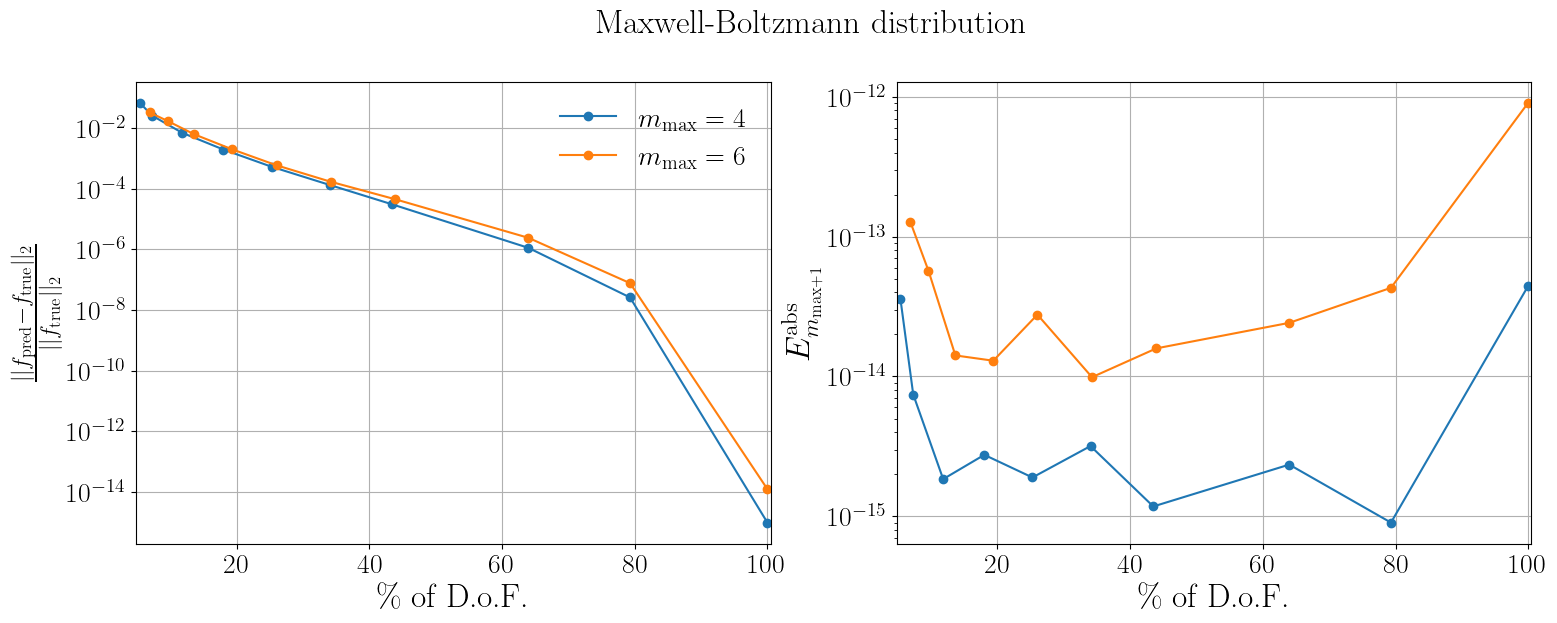

In [362]:
plot_L2_and_next_errors(path_to_output_dir, path_to_plots_dir, "Maxwell_Boltzmann", "Maxwell-Boltzmann distribution", 40, 4, 6, dof_rel=True)

3.500738225525084e-08
6.967894599931332e-09


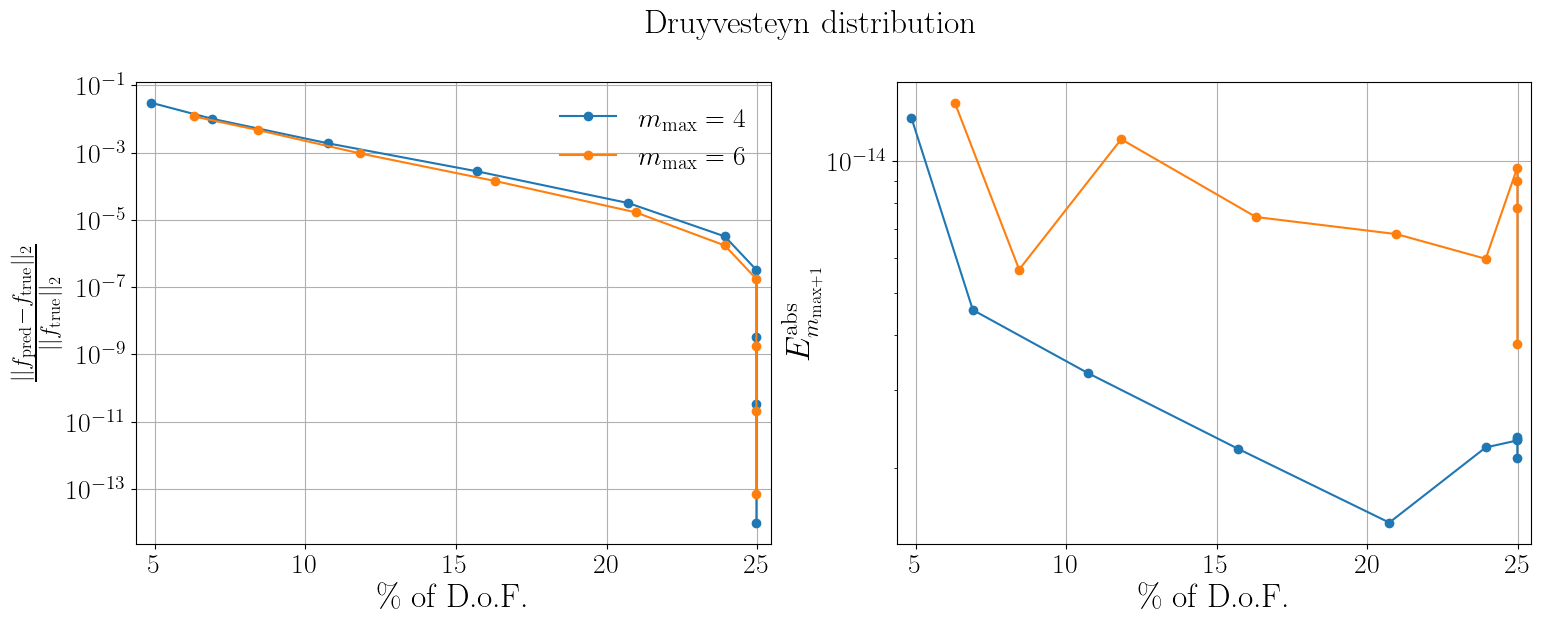

In [363]:
plot_L2_and_next_errors(path_to_output_dir, path_to_plots_dir, "Druyvesteyn", "Druyvesteyn distribution", 40, 4, 6, dof_rel=True)

3.847502882072864e-09
Total sum of |M_next| = 1424.4030284467487
1.2450324602096129e-08
Total sum of |M_next| = 42389.414199063736


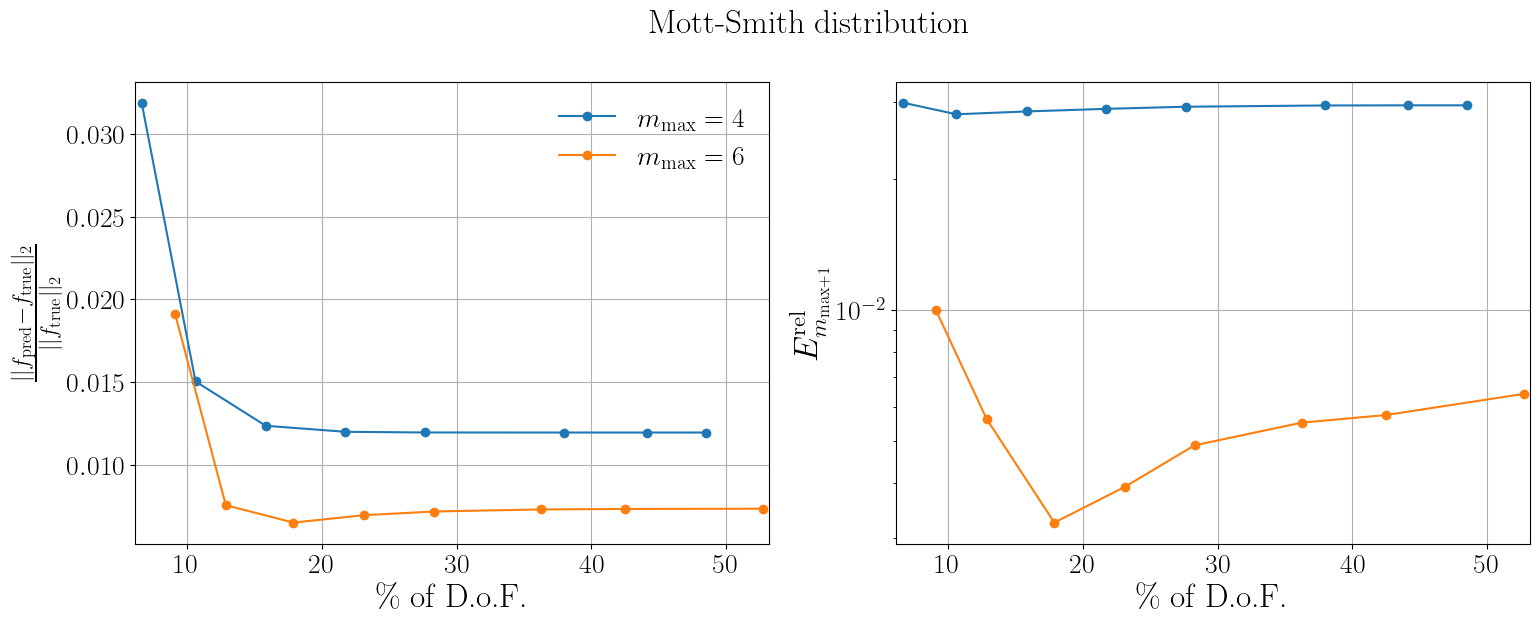

In [366]:
plot_L2_and_next_errors(path_to_output_dir, path_to_plots_dir, "Mott_Smith", "Mott-Smith distribution", 40, 4, 6, dof_rel=True, log_1=False, log_2=True, rel_moment_err=True)

In [367]:
def plot_L2_and_next_errors_parameter_study(path_to_dir, output_path, vdf_name, figlabel, n_v, m1, threshold_array, threshold_labels, dof_rel=True, log_1=True, log_2=True, rel_moment_err=False):

    fig = plt.figure(figsize=(18,6))

    ax1 = fig.add_subplot(1,2,1)
    ax2 = fig.add_subplot(1,2,2)

    for eps, eps_label in zip(threshold_array, threshold_labels):
        path_M1 = f"{path_to_dir}/{vdf_name}{eps}_constraint_M_upto{m1}_{n_v}.h5"
        data1 = compute_L2_and_next_moment_abs_error(path_M1, rel_moment_err)
        
        dofs1 = [n_v**3 - x for x in data1[0]]
        
        # mind = min([min(dofs1), min(dofs2)])
        
        # xl = [mind-300, maxd+300]
        
        if dof_rel:
            dofs1 = [100 * x/n_v**3 for x in dofs1]
            # xl = [100 * x/n_v**3 for x in xl]
    
        ax1.plot(dofs1, [x/data1[3] for x in data1[2]], '-o', label=r"$\varepsilon=" + f"{eps_label}$", linewidth=lw)
        
        ax2.plot(dofs1, data1[1], '-o', linewidth=lw)

    if log_1:
        ax1.set_yscale("log")
    
    if log_2:
        ax2.set_yscale("log")
    
    
    ax1.legend(fontsize=legend_size, frameon=False, loc="best")

    for ax in [ax1, ax2]:
        ax.grid(":")
        ax.tick_params(axis='both', labelsize=tick_size)
        if dof_rel:
            ax.set_xlabel("\% of D.o.F.", fontsize=label_size)
        else:
            ax.set_xlabel("D.o.F.", fontsize=label_size)
        # ax.set_xlim(xl)
        
    ax1.set_ylabel(r"$\frac{||f_{\mathrm{pred}} - f_{\mathrm{true}}||_2}{||f_{\mathrm{true}}||_2}$", fontsize=label_size)

    if rel_moment_err == False:
        ax2.set_ylabel(r"$E_{m_{\mathrm{max}+1}}^{\mathrm{abs}}$", fontsize=label_size)
    else:
        ax2.set_ylabel(r"$E_{m_{\mathrm{max}+1}}^{\mathrm{rel}}$", fontsize=label_size)

    fig.suptitle(figlabel, y=1.0, fontsize=label_size)
    # if err_rel_abs_list[plot_index] == "a":
    #     ax.set_ylabel(r"$\sum_{i+j=" + f"{m_constraint+1}" + "} |M_{i,j}^{true} - M_{i,j}^{pred}|$", fontsize=label_size)
    # else:
    #     ax.set_ylabel(r"$\sum_{i+j=" + f"{m_constraint+1}" + "} |M_{i,j}^{true} - M_{i,j}^{pred}|$ / $\sum_{i+j=" + f"{m_constraint+1}" + "} |M_{i,j}^{true}|$", fontsize=label_size)

    # ax.set_xlim([min(dofs), int(nv)**2])

    fig.savefig(f"{output_path}/{vdf_name}_{n_v}_errors_{m1}_paramstudy.pdf", bbox_inches="tight")

1.2660711375296927e-08
Total sum of |M_next| = 42389.414199063736
1.172354904201321e-08
Total sum of |M_next| = 42389.414199063736
1.3366340630677345e-05
Total sum of |M_next| = 42389.414199063736


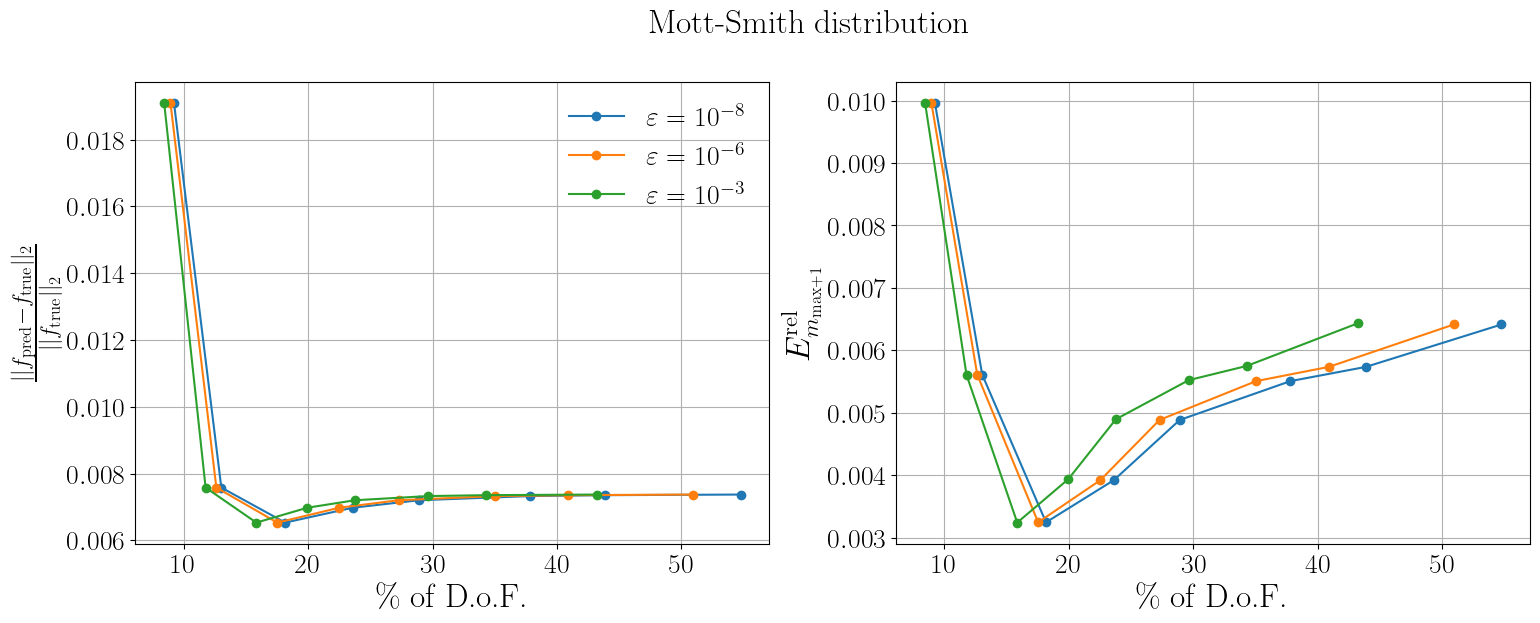

In [368]:
plot_L2_and_next_errors_parameter_study(path_to_output_dir, path_to_plots_dir, "Mott_Smith", "Mott-Smith distribution", 40, 6, ["1.0e-8", "1.0e-6", "0.001"], [r"10^{-8}", r"10^{-6}", r"10^{-3}"],
                                        dof_rel=True, log_1=False, log_2=False, rel_moment_err=True)

In [369]:
lambda_values_dict = {
    0.0: "-8",
    1e-10: "10^{-10}",
    1e-8: "10^{-8}",
    1e-7: "10^{-7}",
    1e-6: "10^{-6}",
    1e-5: "10^{-5}",
    1e-4: "10^{-4}",
    1e-3: "10^{-3}",
    1e-2: "10^{-2}",
    1e-1: "0.1",
    1.0: "0",
    10.0: "10",
    100.0: "100",
}

In [388]:
def plot_vdf(path_to_dir, output_path, vdf_name, figlabel, prefix, n_v, m1, slice_vz, sparsity_index):
    # mosaic = """AABB
    #             .CC."""

        
    # fig, ax_dict = plt.subplot_mosaic(mosaic, figsize=(18,12))
    # ax1, ax2, ax3 = ax_dict['A'], ax_dict['B'], ax_dict['C']

    fig = plt.figure(figsize=(18,12))

    ax1 = fig.add_subplot(2,2,1)
    ax2 = fig.add_subplot(2,2,2)
    ax3 = fig.add_subplot(2,2,3)
    ax4 = fig.add_subplot(2,2,4)
    
    path_M1 = f"{path_to_dir}/{vdf_name}_constraint_M_upto{m1}_{n_v}.h5"

    with h5py.File(path_M1, "r") as f:
        vz = f["grid"][2,slice_vz,0,0]  # in python ordering is vel * n_vz * n_vy * n_vx

        print("slice at", slice_vz, "vz =", vz)
        print((f["grid"].shape))

        data1 = f["vdf_hidden_truth"][slice_vz, :, :]
        data2 = f["solutions"][sparsity_index[0], slice_vz, :, :] * f["weighting_function"][slice_vz, :, :]
        data3 = f["solutions"][sparsity_index[1], slice_vz, :, :] * f["weighting_function"][slice_vz, :, :]
        data4 = f["solutions"][sparsity_index[2], slice_vz, :, :] * f["weighting_function"][slice_vz, :, :]

        l1 = f["lambdas"][sparsity_index[0]]
        l2 = f["lambdas"][sparsity_index[1]]
        l3 = f["lambdas"][sparsity_index[2]]
        print(l1, l2, l3)

        print(lambda_values_dict[l1], lambda_values_dict[l2], lambda_values_dict[l3])
        
        # Find global min and max
        global_min = min(data1.min(), data2.min(), data3.min(), data4.min())
        global_max = max(data1.max(), data2.max(), data3.max(), data4.max())

        print(data1.min(), data2.min(), data3.min(), data4.min())
        print(data1.max(), data2.max(), data3.max(), data4.max())

        vx = f["grid"][0,slice_vz,0,:]
        vy = f["grid"][1,slice_vz,:,0]

        X, Y = np.meshgrid(vx, vy)
        
        ax1.pcolormesh(X, Y, data1, vmin=global_min, vmax=global_max, cmap='viridis')
        pc2 = ax2.pcolormesh(X, Y, data2, vmin=global_min, vmax=global_max, cmap='viridis')
        ax3.pcolormesh(X, Y, data3, vmin=global_min, vmax=global_max, cmap='viridis')
        ax4.pcolormesh(X, Y, data4, vmin=global_min, vmax=global_max, cmap='viridis')

        
        # ax1.pcolormesh(X, Y, data1, cmap='viridis')
        # pc2 = ax2.pcolormesh(X, Y, data2, cmap='viridis')
        # ax3.pcolormesh(X, Y, data3, cmap='viridis')
        # ax4.pcolormesh(X, Y, data4, cmap='viridis')
        
        for ax in [ax1, ax2, ax3, ax4]:
            ax.set_aspect('equal')
            ax.tick_params(axis='both', labelsize=tick_size)
            ax.set_xlabel("$v_{x}$", fontsize=label_size)
            ax.set_ylabel("$v_{y}$", fontsize=label_size)

        sparsity_degree = f["sparsity_degree"][:]
        dofs1 = n_v**3 - sparsity_degree[sparsity_index[0]]
        dofs2 = n_v**3 - sparsity_degree[sparsity_index[1]]
        dofs3 = n_v**3 - sparsity_degree[sparsity_index[2]]

        ax1.set_title("Ground truth", fontsize=legend_size)
        
        for ll, dd, ax in zip([l1, l2, l3], [dofs1, dofs2, dofs3], [ax2,ax3,ax4]):
            ax.set_title(prefix + r'$\tilde{\lambda}=' + lambda_values_dict[ll] + "$; \% of D.o.F = " + f"{100 * dd/(n_v**3):.1f}", fontsize=legend_size)
        
        plt.tight_layout()
        # Add colorbar
        cbar = plt.colorbar(pc2, ax=[ax1, ax2, ax3, ax4], orientation='vertical', fraction=0.02, pad=0.08)
        cbar.ax.tick_params(labelsize=tick_size)  # Set the font size for the tick labels
        cbar.set_label('VDF', fontsize=label_size)  # Set the font size for the colorbar label

    fig.suptitle(figlabel, y=1.025, fontsize=label_size)
    fig.savefig(f"{output_path}/{vdf_name}_vzslice{slice_vz}.png", bbox_inches="tight", dpi=300)

slice at 20 vz = 0.1025641025641022
(3, 40, 40, 40)
1e-10 1e-05 0.1
10^{-10} 10^{-5} 0.1
2.2505219980777256e-15 0.0 0.0 0.0
0.17400817524130432 0.17400693816924137 0.17116772785970574 0.15759434393823574


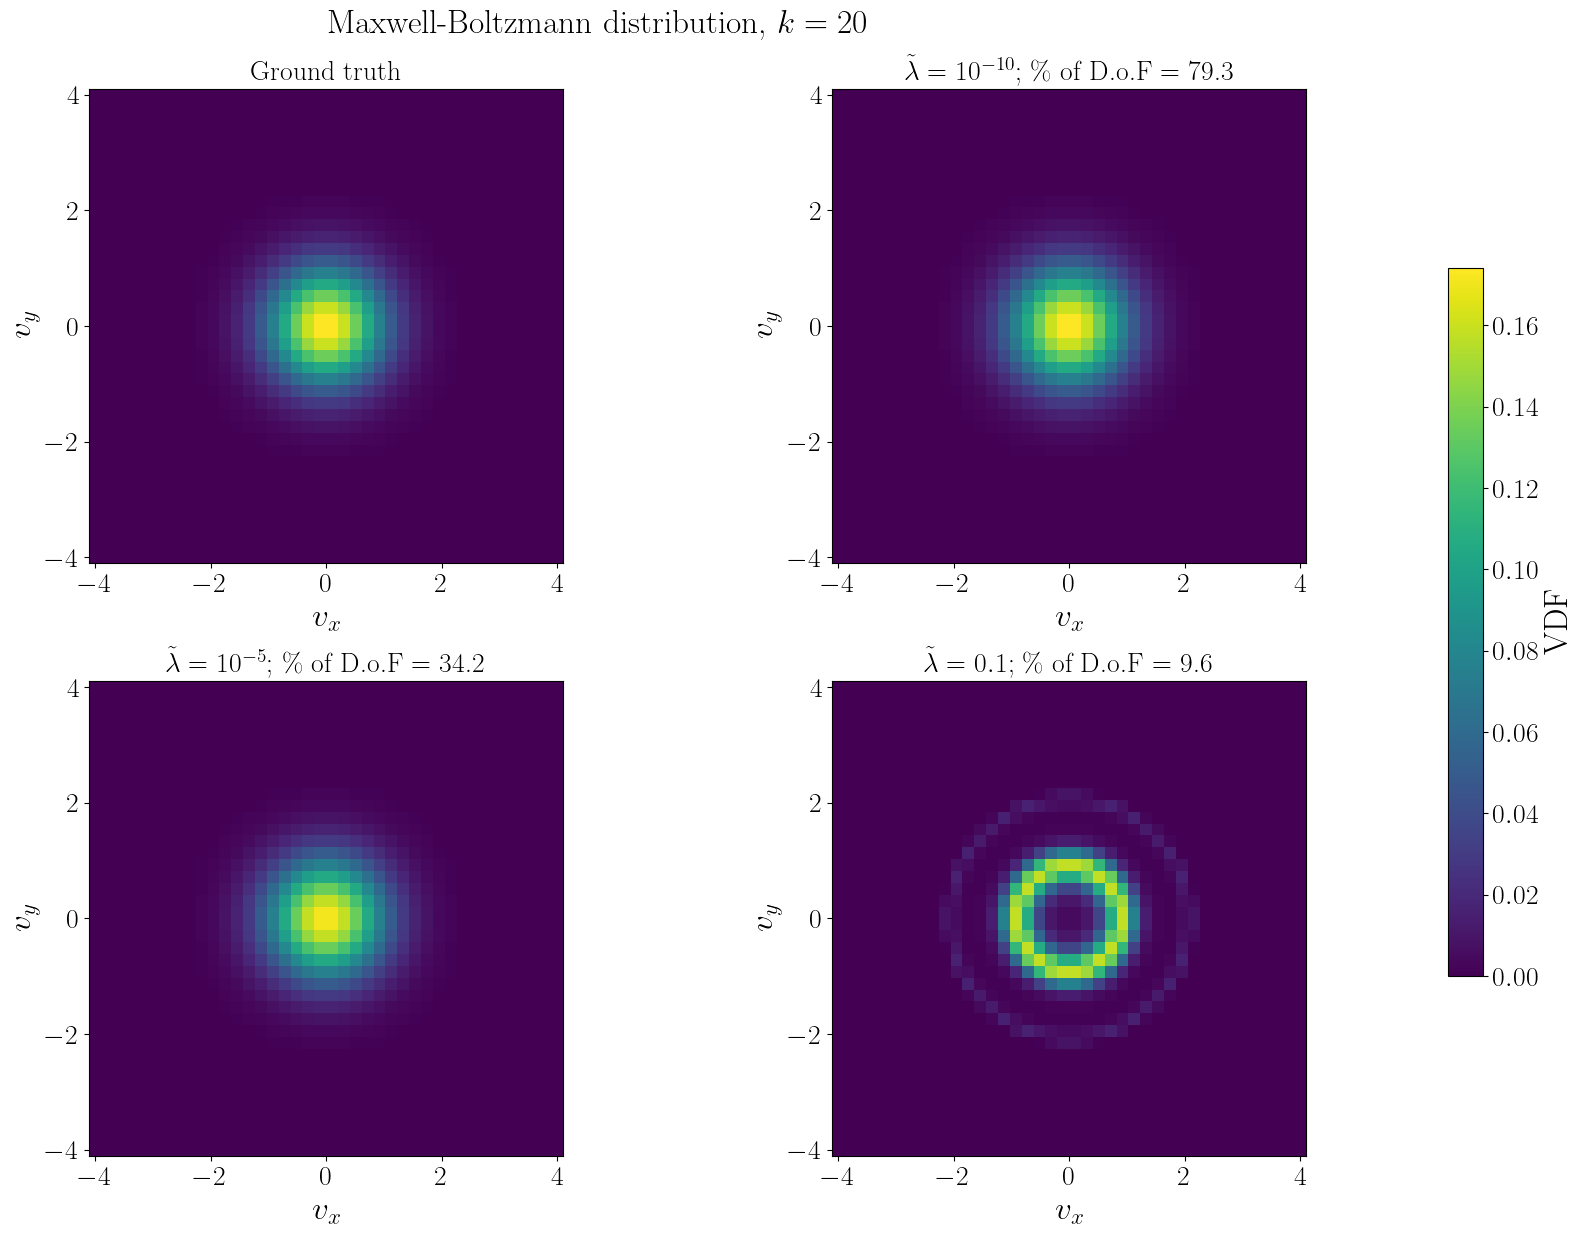

In [389]:
kslice = 20
plot_vdf(path_to_output_dir, path_to_plots_dir, "Maxwell_Boltzmann", f"Maxwell-Boltzmann distribution, $k={kslice}$", "", 40, 6, kslice, [1,4,-2])

slice at 20 vz = 0.1025641025641022
(3, 40, 40, 40)
1e-10 1e-05 0.1
10^{-10} 10^{-5} 0.1
5.563871040565565e-110 0.0 0.0 0.0
0.08992494969060152 0.08992494940337017 0.08990071628871642 0.09702666643043514


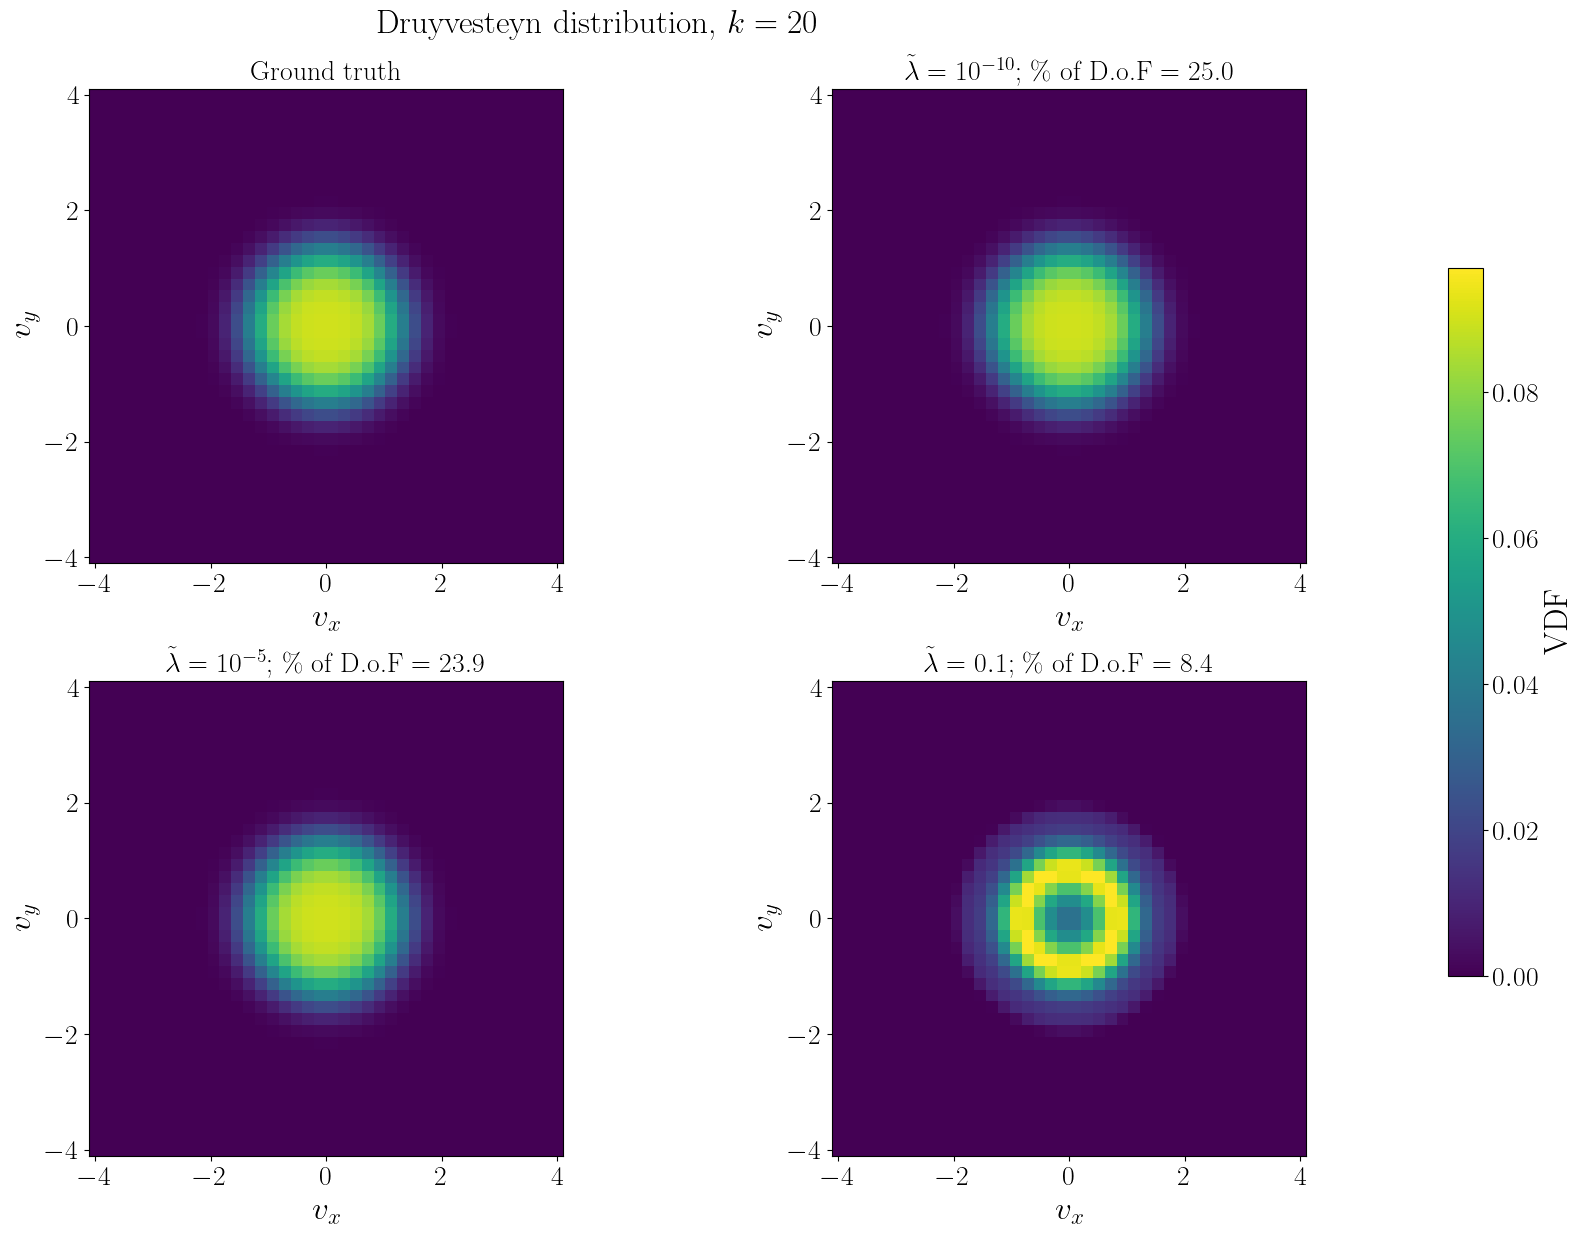

In [390]:
kslice = 20
plot_vdf(path_to_output_dir, path_to_plots_dir, "Druyvesteyn", f"Druyvesteyn distribution, $k={kslice}$", "", 40, 6, kslice, [1,4,-2])

slice at 20 vz = 0.2564102564102555
(3, 40, 40, 40)
1e-10 1e-05 0.001
10^{-10} 10^{-5} 10^{-3}
5.188195372167473e-20 0.0 0.0 0.0
0.035058893294017866 0.023123632436333422 0.023649127136956955 0.03004154536860466


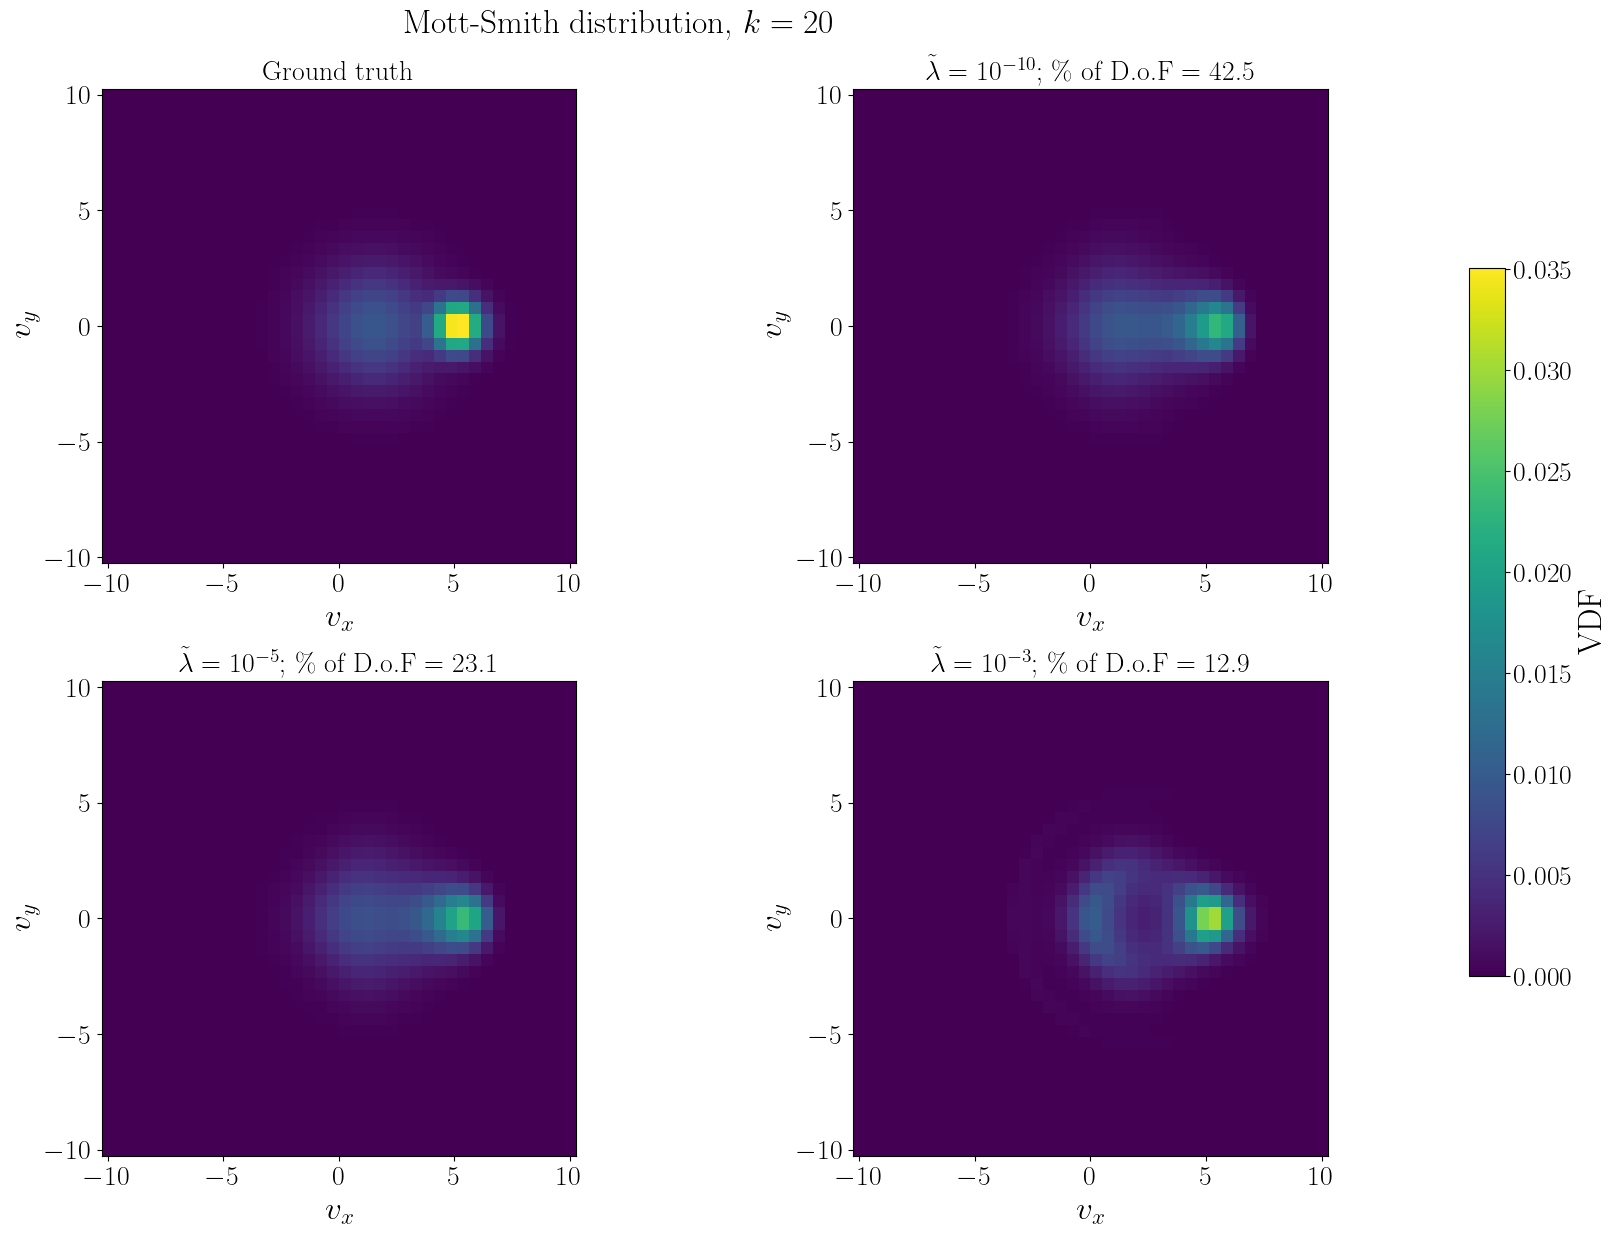

In [391]:
kslice = 20
plot_vdf(path_to_output_dir, path_to_plots_dir, "Mott_Smith", f"Mott-Smith distribution, $k={kslice}$", "", 40, 6, kslice, [1,4,-2])

slice at 40 vz = -0.3700787401574803
(3, 128, 128, 128)
1e-08 0.0001 0.01
10^{-8} 10^{-4} 10^{-2}
6.0839486812144e-30 0.0 0.0 0.0
0.08668405571582036 0.07591616591668603 0.07836795388182295 0.09361810107417083
slice at 64 vz = 0.007874015748031482
(3, 128, 128, 128)
1e-08 0.0001 0.01
10^{-8} 10^{-4} 10^{-2}
1.4662166007985353e-33 0.0 0.0 0.0
65.12029690439235 55.677133818842265 54.55321788472123 50.990807554692225


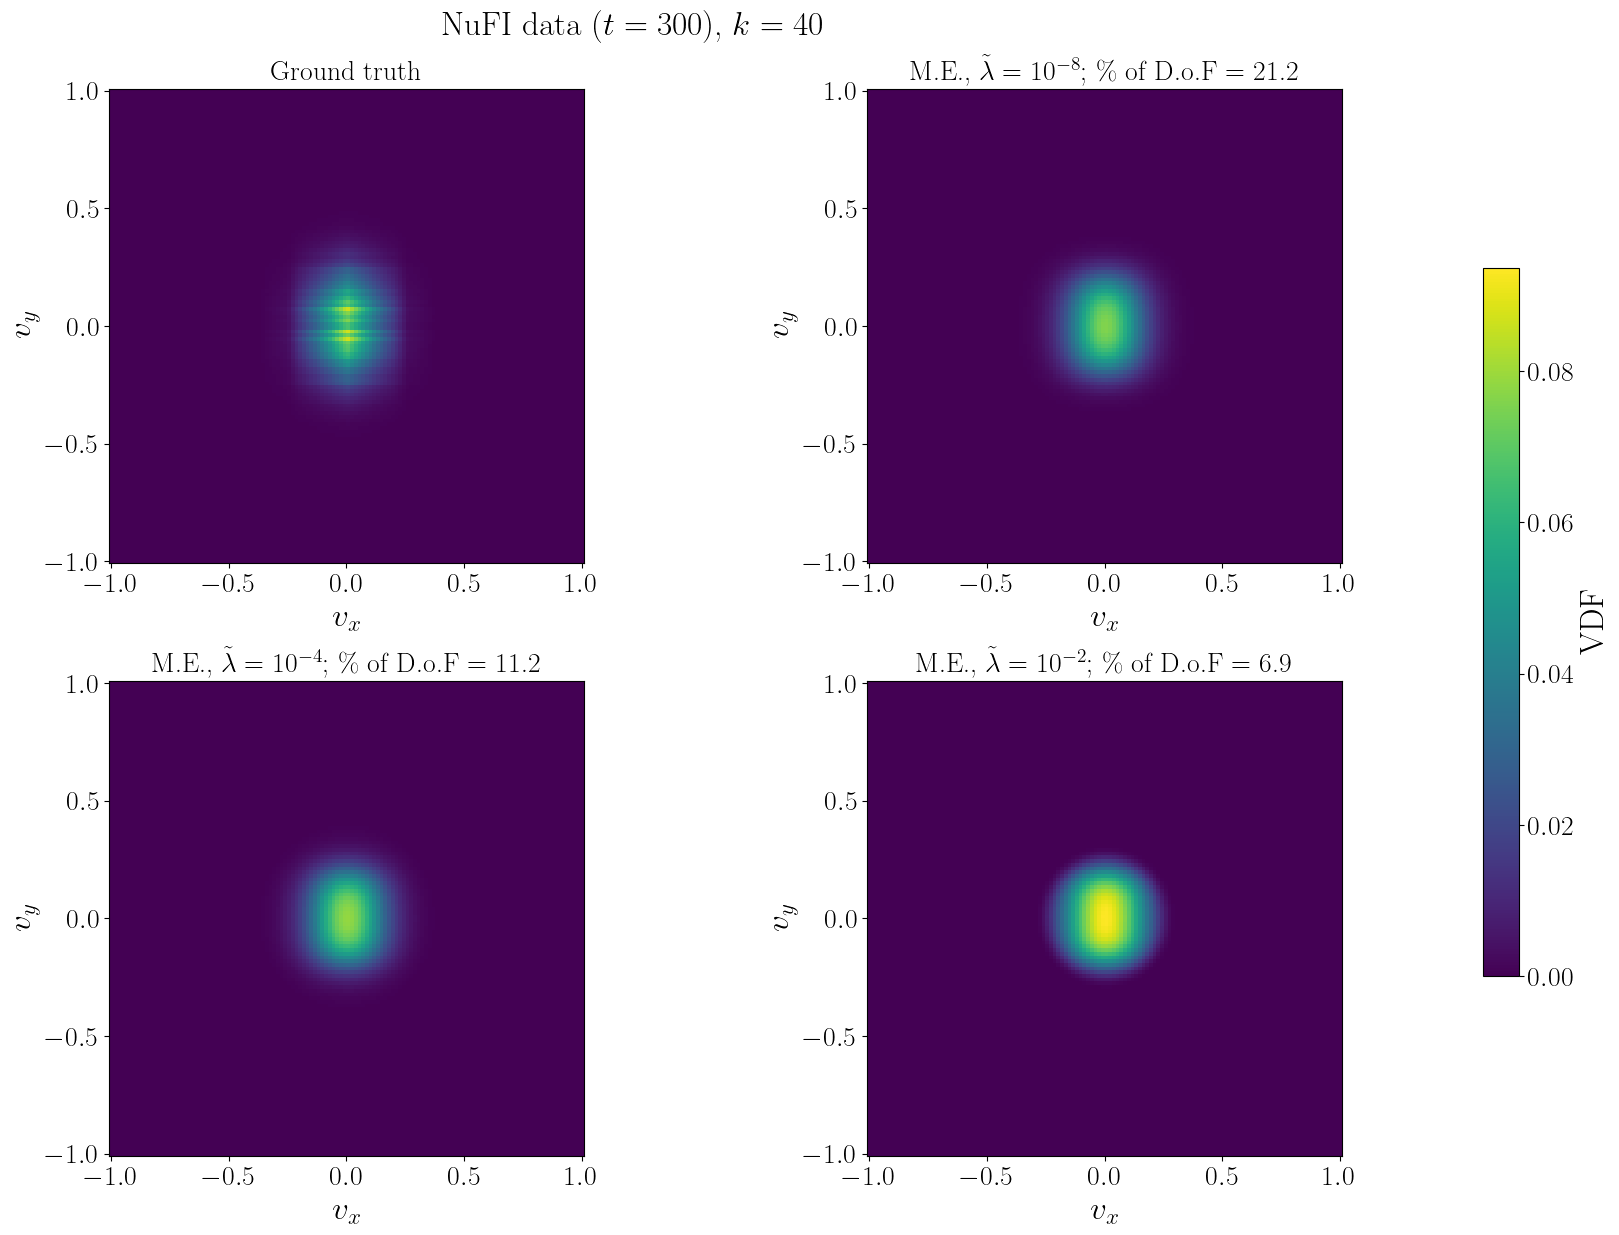

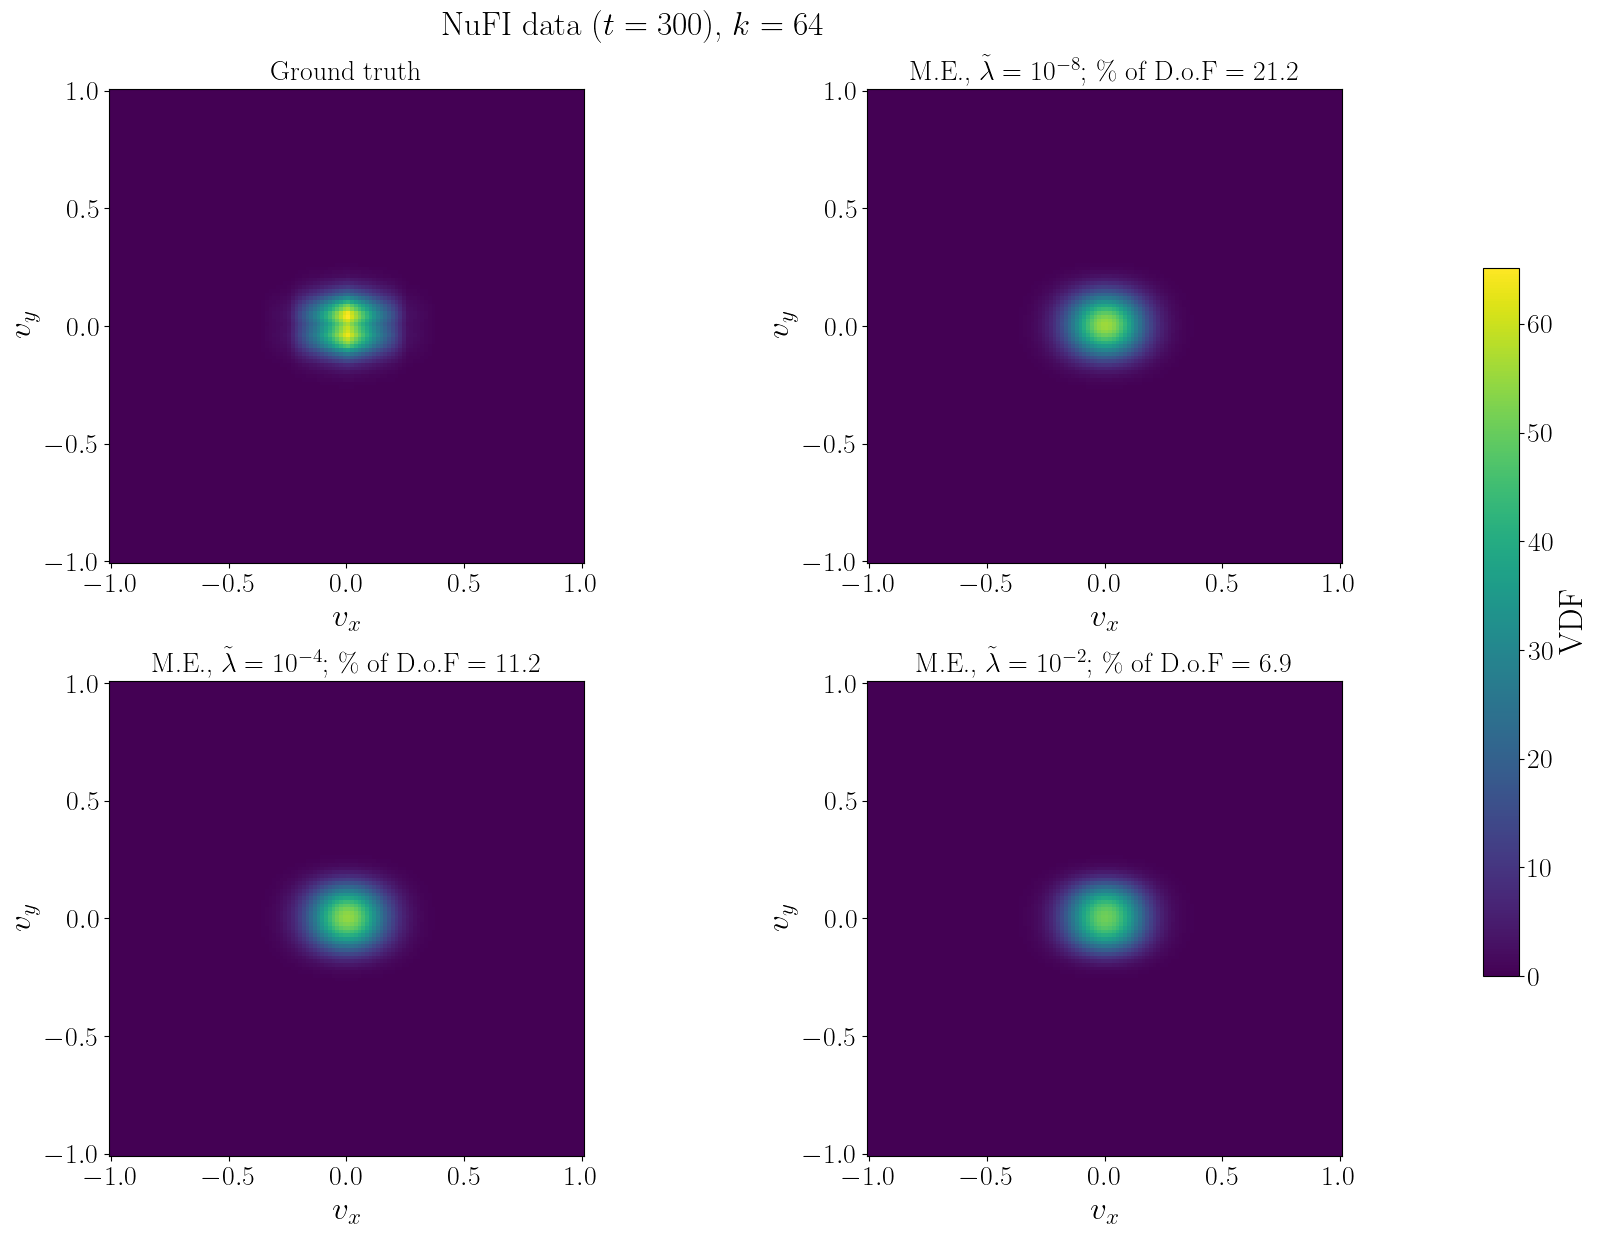

In [392]:
for kslice in [40, 64]:
    plot_vdf(path_to_output_dir, path_to_plots_dir, "ME_MBw_NuFI_300_2", f"NuFI data ($t=300$), $k={kslice}$", "M.E., ", 128, 6, kslice, [1,3,-4])

slice at 40 vz = -0.3700787401574803
(3, 128, 128, 128)
1e-08 0.01 1.0
10^{-8} 10^{-2} 0
6.0839486812144e-30 0.0 0.0 0.0
0.08668405571582036 0.08668295520958036 0.10036965325795696 0.08805154967204322
slice at 64 vz = 0.007874015748031482
(3, 128, 128, 128)
1e-08 0.01 1.0
10^{-8} 10^{-2} 0
1.4662166007985353e-33 0.0 0.0 0.0
65.12029690439235 65.11977689977937 63.05946585995455 48.904108992186345
slice at 32 vz = -0.49606299212598426
(3, 128, 128, 128)
1e-08 0.01 1.0
10^{-8} 10^{-2} 0
2.9397296811251896e-30 0.0 0.0 0.0
0.0007693714905003911 0.0007697840591001475 1.5471328575972315e-06 0.0


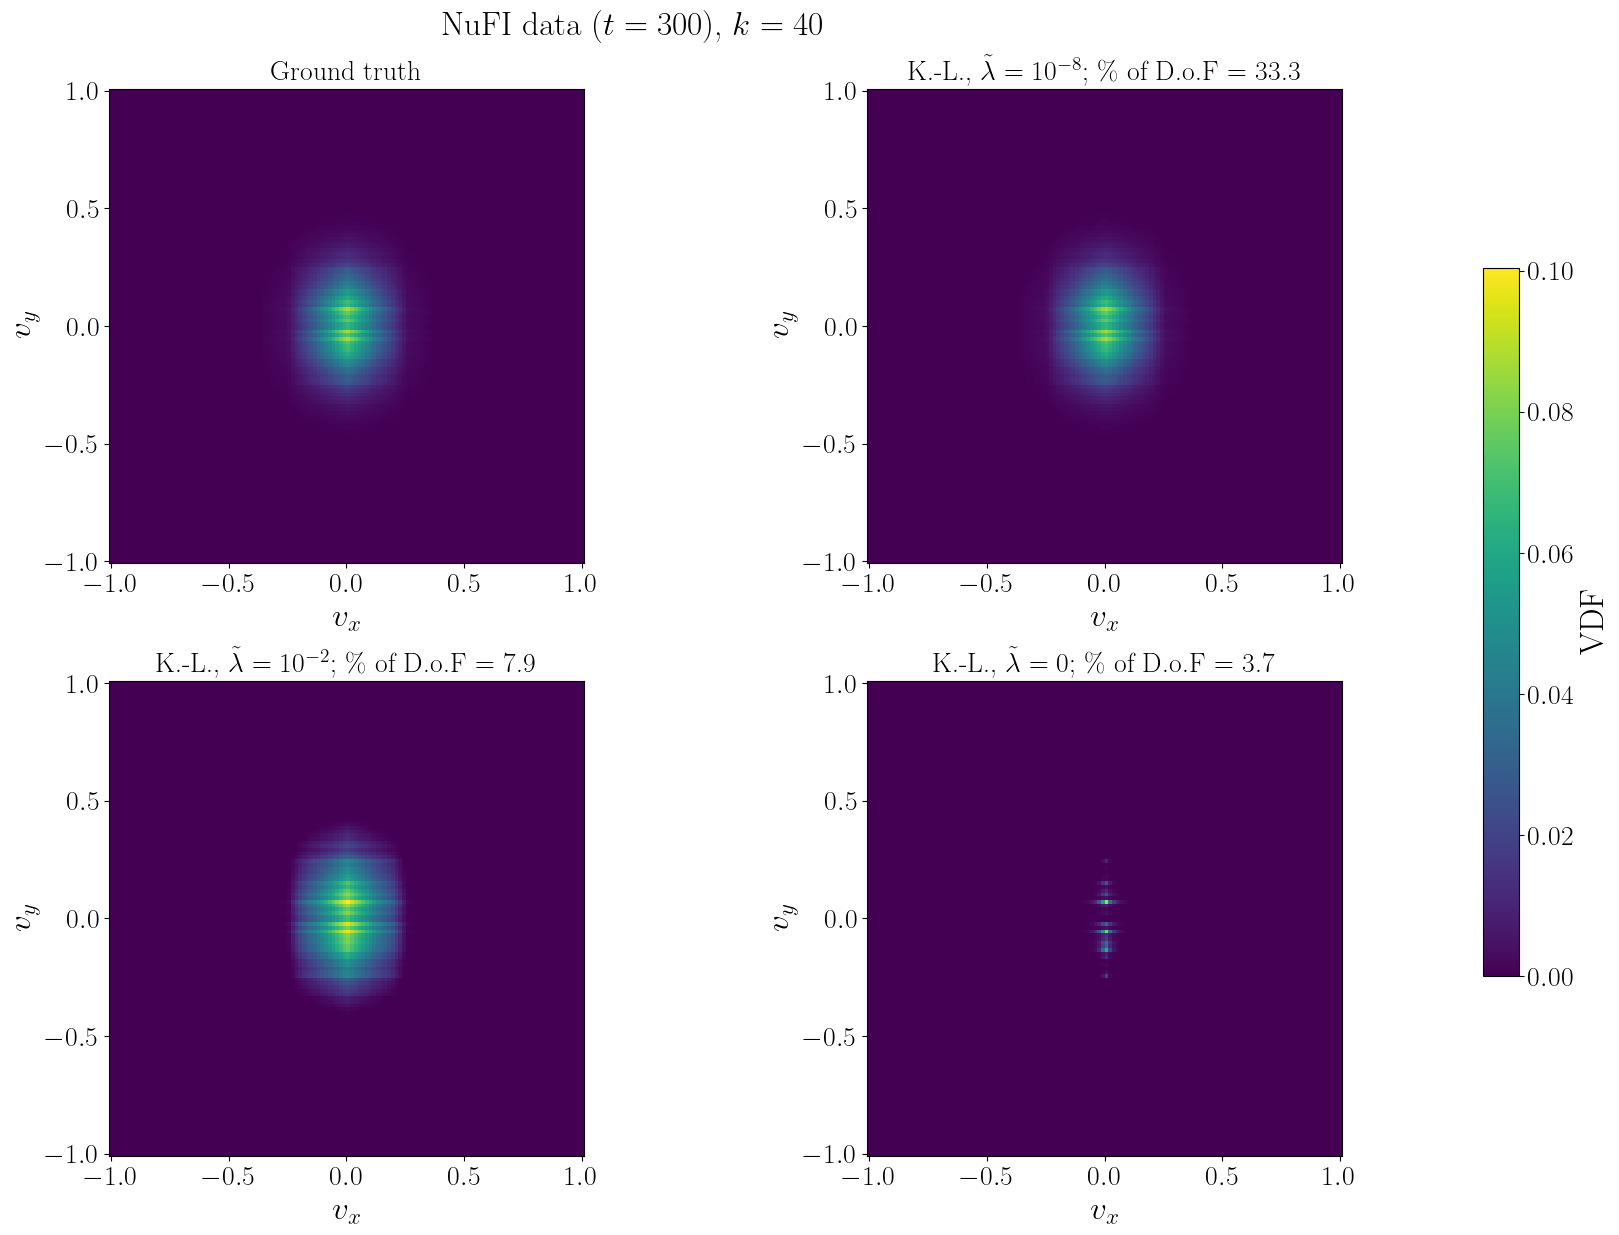

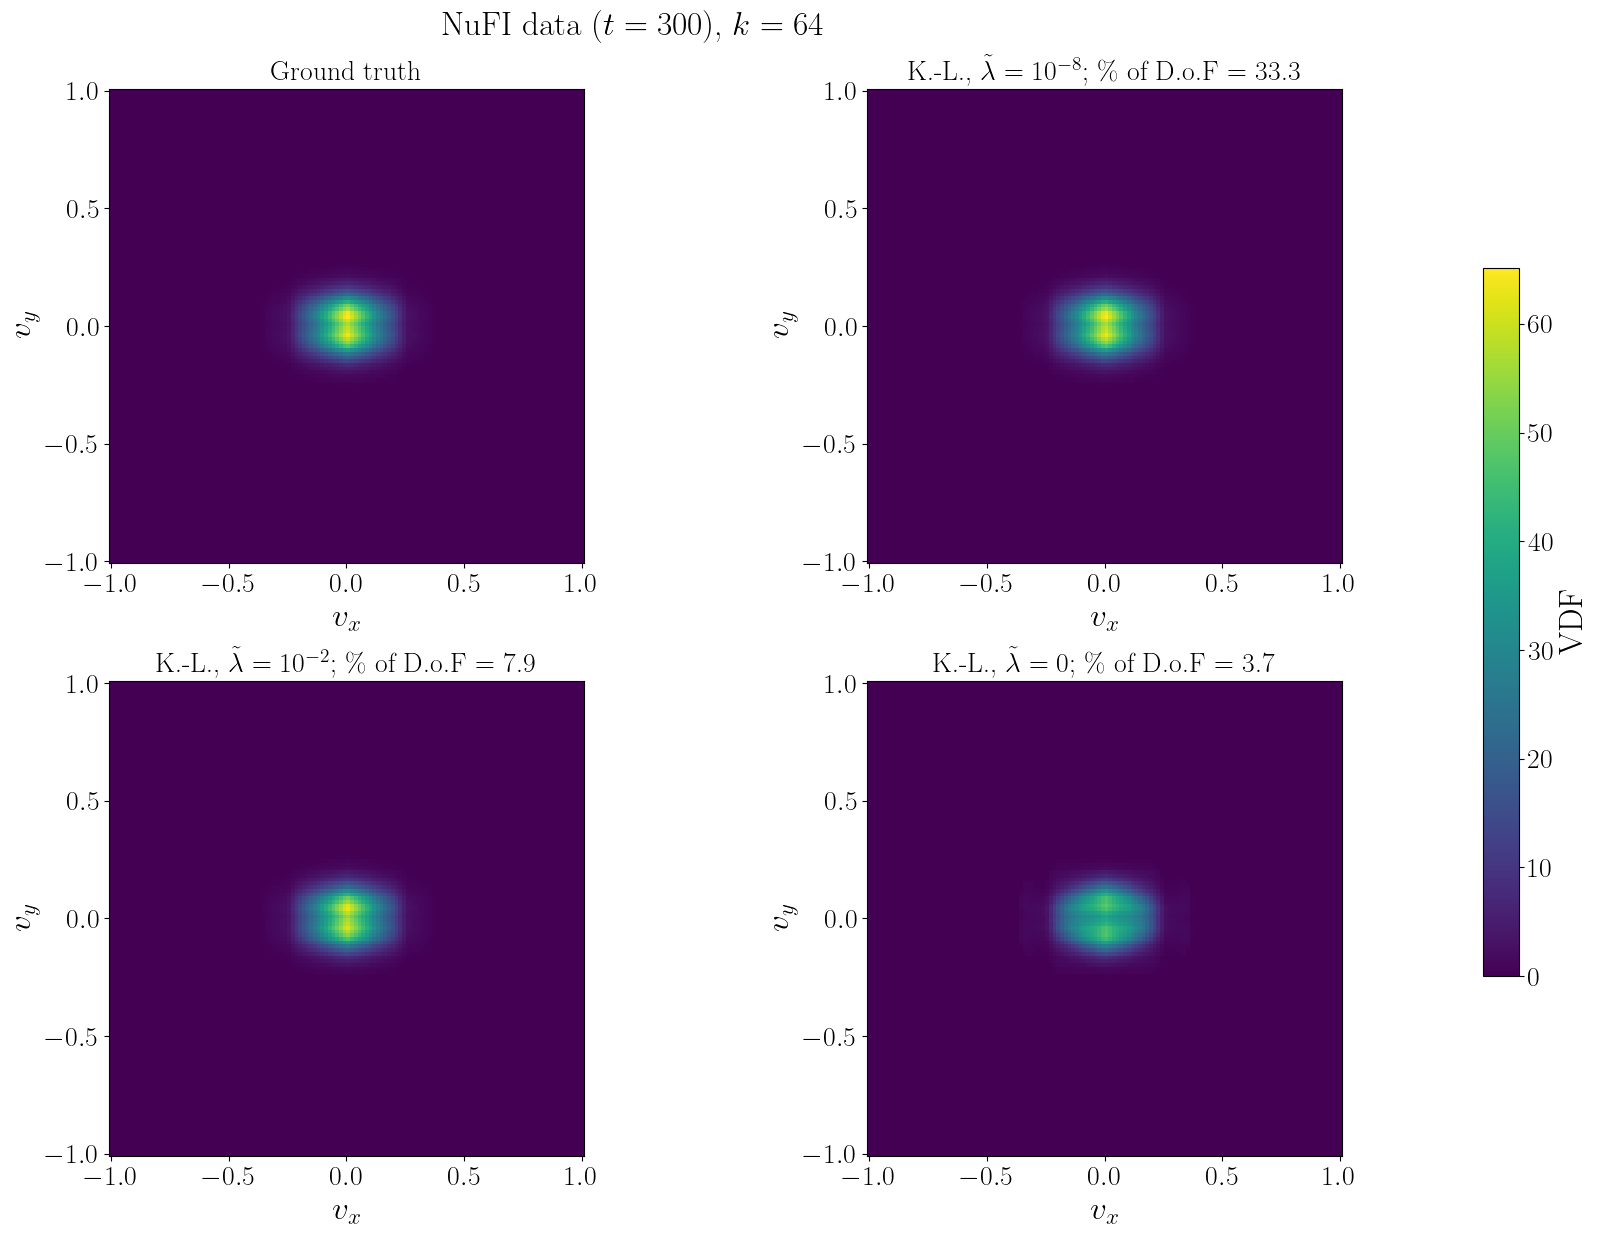

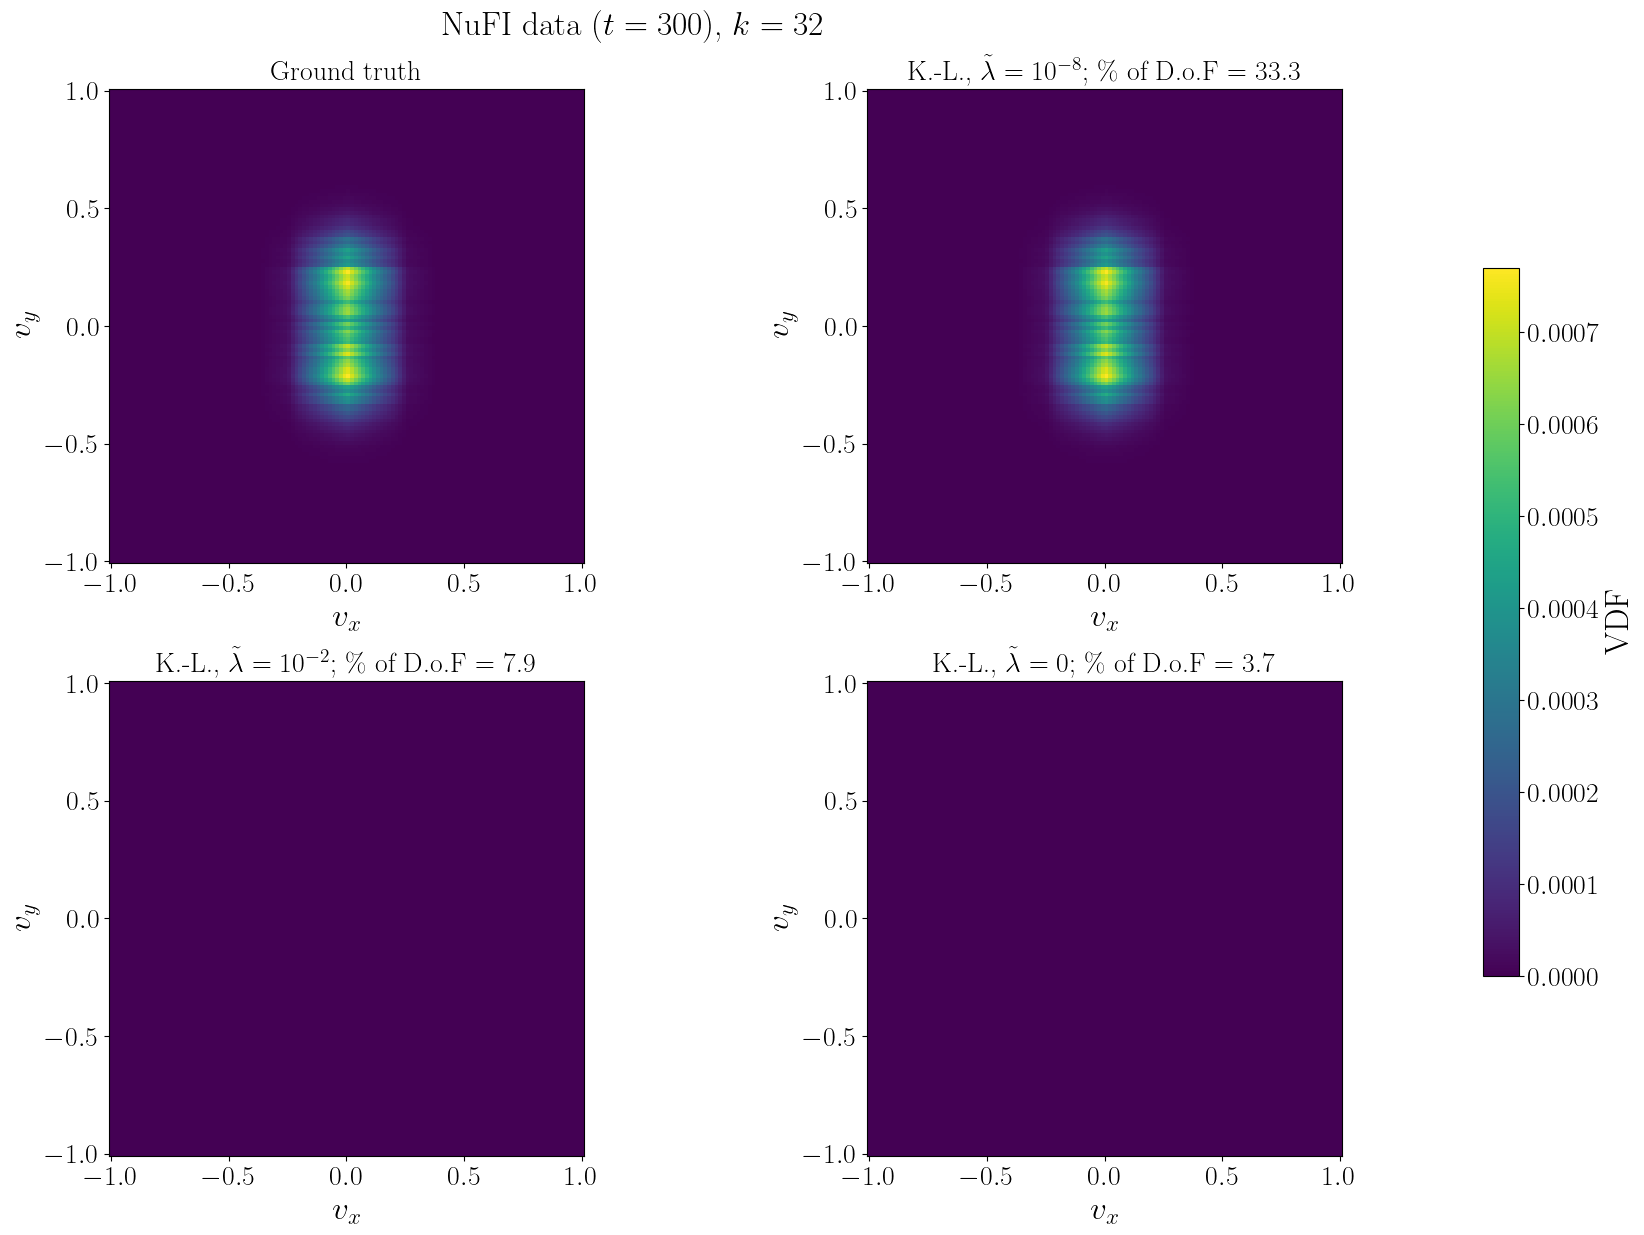

In [394]:
for kslice in [40, 64, 32]:
    plot_vdf(path_to_output_dir, path_to_plots_dir, "KL_VDFw_NuFI_300_2", f"NuFI data ($t=300$), $k={kslice}$", "K.-L., ", 128, 6, kslice, [1,-4,-3])

In [396]:
def plot_L2_and_next_errors_NuFI(path_to_dir, output_path, n_v, m1, m2, t, dof_rel=True, log_1=True, log_2=True, rel_moment_err=False):
    path_M1_ME = f"{path_to_dir}/ME_MBw_NuFI_{t}_2_constraint_M_upto{m1}_{n_v}.h5"
    path_M2_ME = f"{path_to_dir}/ME_MBw_NuFI_{t}_2_constraint_M_upto{m2}_{n_v}.h5"
    
    path_M1_KL = f"{path_to_dir}/KL_VDFw_NuFI_{t}_2_constraint_M_upto{m1}_{n_v}.h5"
    path_M2_KL = f"{path_to_dir}/KL_VDFw_NuFI_{t}_2_constraint_M_upto{m2}_{n_v}.h5"
    data1_ME = compute_L2_and_next_moment_abs_error(path_M1_ME, rel_moment_err)
    data2_ME = compute_L2_and_next_moment_abs_error(path_M2_ME, rel_moment_err)
    
    data1_KL = compute_L2_and_next_moment_abs_error(path_M1_KL, rel_moment_err)
    data2_KL = compute_L2_and_next_moment_abs_error(path_M2_KL, rel_moment_err)
    
    dofs1_ME = [n_v**3 - x for x in data1_ME[0]]
    dofs2_ME = [n_v**3 - x for x in data2_ME[0]]
    dofs1_KL = [n_v**3 - x for x in data1_KL[0]]
    dofs2_KL = [n_v**3 - x for x in data2_KL[0]]
    
    mind = min([min(dofs1_ME), min(dofs2_ME), min(dofs1_KL), min(dofs2_KL)])
    maxd = max([max(dofs1_ME), max(dofs2_ME), max(dofs1_KL), max(dofs2_KL)])
    
    xl = [mind-300, maxd+300]
    
    if dof_rel:
        dofs1_ME = [100 * x/n_v**3 for x in dofs1_ME]
        dofs2_ME = [100 * x/n_v**3 for x in dofs2_ME]
        dofs1_KL = [100 * x/n_v**3 for x in dofs1_KL]
        dofs2_KL = [100 * x/n_v**3 for x in dofs2_KL]
        xl = [100 * x/n_v**3 for x in xl]
    
    fig = plt.figure(figsize=(18,6))

    ax1 = fig.add_subplot(1,2,1)
    l1 = ax1.plot(dofs1_ME, [x/data1_ME[3] for x in data1_ME[2]], '--o', label=r"M.E., $m_{\mathrm{max}} = " + f"{m1}$", linewidth=lw)
    l2 = ax1.plot(dofs2_ME, [x/data2_ME[3] for x in data2_ME[2]], '--o', label=r"M.E., $m_{\mathrm{max}} = " + f"{m2}$", linewidth=lw)
    
    ax1.plot(dofs1_KL, [x/data1_KL[3] for x in data1_KL[2]], '-d', label=r"K.L., $m_{\mathrm{max}} = " + f"{m1}$", linewidth=lw, color=l1[0].get_color())
    ax1.plot(dofs2_KL, [x/data2_KL[3] for x in data2_KL[2]], '-d', label=r"K.L., $m_{\mathrm{max}} = " + f"{m2}$", linewidth=lw, color=l2[0].get_color())
    
    ax2 = fig.add_subplot(1,2,2)
    l1 = ax2.plot(dofs1_ME, data1_ME[1], '--o', linewidth=lw, color=l1[0].get_color())
    l2 = ax2.plot(dofs2_ME, data2_ME[1], '--o', linewidth=lw, color=l2[0].get_color())
    
    ax2.plot(dofs1_KL, data1_KL[1], '-d', linewidth=lw, color=l1[0].get_color())
    ax2.plot(dofs2_KL, data2_KL[1], '-d', linewidth=lw, color=l2[0].get_color())

    if log_1:
        ax1.set_yscale("log")
    
    if log_2:
        ax2.set_yscale("log")
    
    ax1.legend(fontsize=legend_size, frameon=False, loc="best")

    for ax in [ax1, ax2]:
        ax.grid(":")
        ax.tick_params(axis='both', labelsize=tick_size)
        if dof_rel:
            ax.set_xlabel("\% of D.o.F.", fontsize=label_size)
        else:
            ax.set_xlabel("D.o.F.", fontsize=label_size)
        ax.set_xlim(xl)
        
    ax1.set_ylabel(r"$\frac{||f_{\mathrm{pred}} - f_{\mathrm{true}}||_2}{||f_{\mathrm{true}}||_2}$", fontsize=label_size)

    if rel_moment_err == False:
        ax2.set_ylabel(r"$E_{m_{\mathrm{max}+1}}^{\mathrm{abs}}$", fontsize=label_size)
    else:
        ax2.set_ylabel(r"$E_{m_{\mathrm{max}+1}}^{\mathrm{rel}}$", fontsize=label_size)
    # if err_rel_abs_list[plot_index] == "a":
    #     ax.set_ylabel(r"$\sum_{i+j=" + f"{m_constraint+1}" + "} |M_{i,j}^{true} - M_{i,j}^{pred}|$", fontsize=label_size)
    # else:
    #     ax.set_ylabel(r"$\sum_{i+j=" + f"{m_constraint+1}" + "} |M_{i,j}^{true} - M_{i,j}^{pred}|$ / $\sum_{i+j=" + f"{m_constraint+1}" + "} |M_{i,j}^{true}|$", fontsize=label_size)

    # ax.set_xlim([min(dofs), int(nv)**2])

    fig.suptitle(f"NuFI data ($t={t}$)", y=1.0, fontsize=label_size)
    fig.savefig(f"{output_path}/NuFI{t}_{n_v}_errors_{m1}_{m2}.pdf", bbox_inches="tight")

1.5747750210898906e-10
Total sum of |M_next| = 2.237702461046109e-05
7.196367846849754e-06
Total sum of |M_next| = 1.518363364479661e-06
3.085079833803299e-11
Total sum of |M_next| = 2.237702461046109e-05
1.3394098625923355e-11
Total sum of |M_next| = 1.518363364479661e-06
1.0577010371695776e-09
Total sum of |M_next| = 4.240822179669623e-05
1.3226969435075737e-10
Total sum of |M_next| = 2.85671620854269e-06
2.0061608934341743e-10
Total sum of |M_next| = 4.240822179669623e-05
4.310893975933176e-10
Total sum of |M_next| = 2.85671620854269e-06
7.491129871965981e-12
Total sum of |M_next| = 5.580130163864816e-05
3.869018762017498e-10
Total sum of |M_next| = 4.528367717888345e-06
1.0762925605691958e-09
Total sum of |M_next| = 5.580130163864816e-05
1.7104672163362067e-06
Total sum of |M_next| = 4.528367717888345e-06


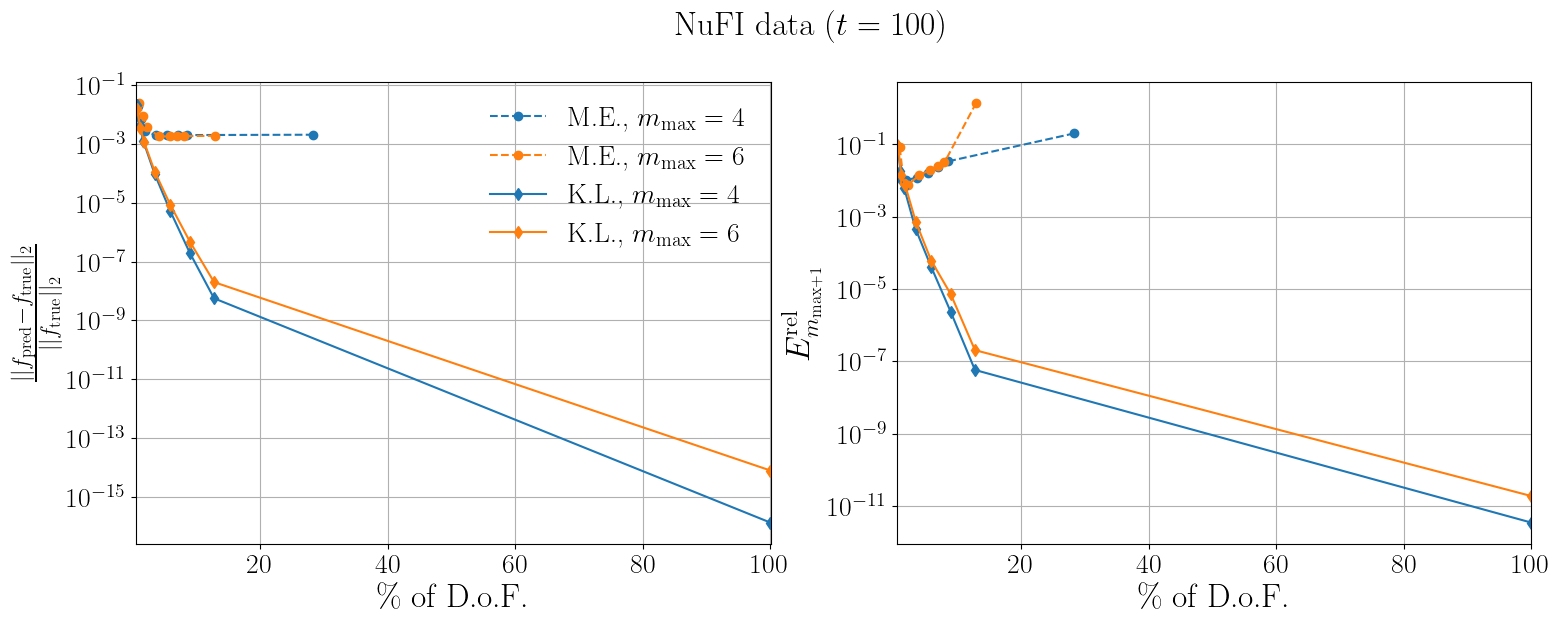

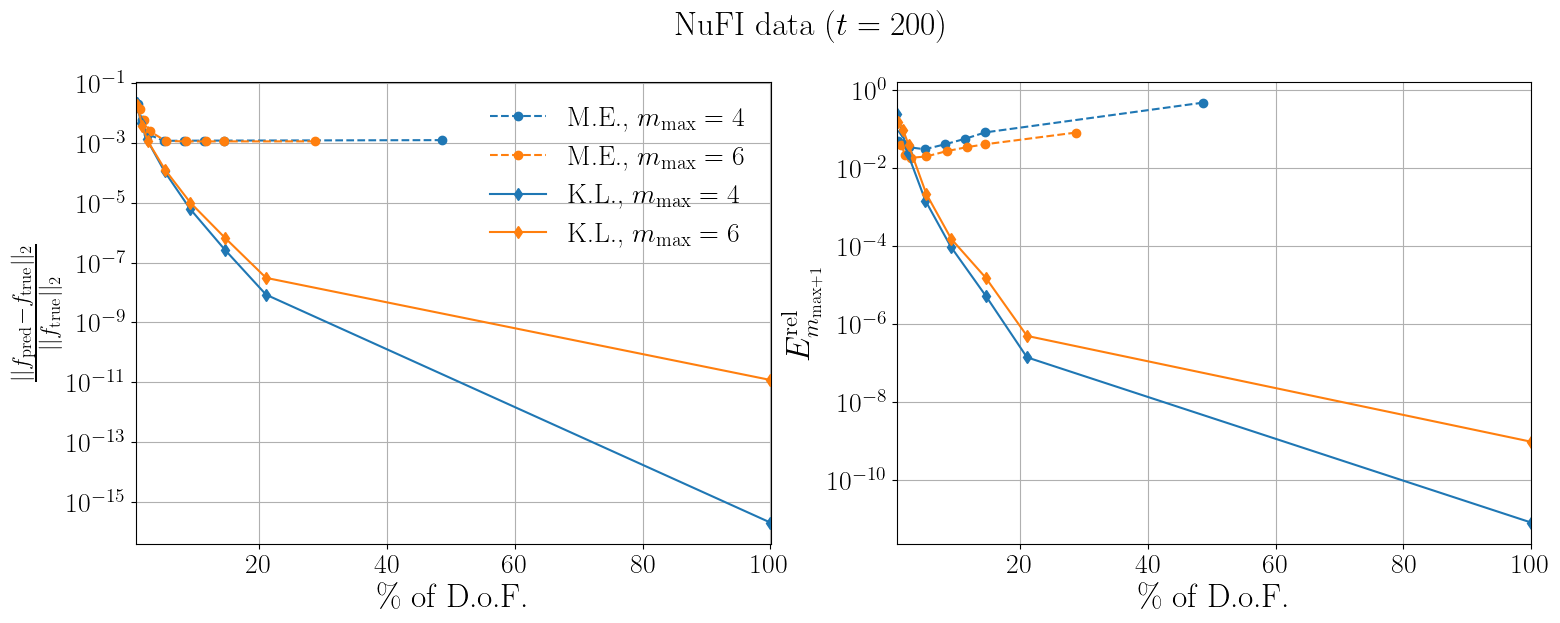

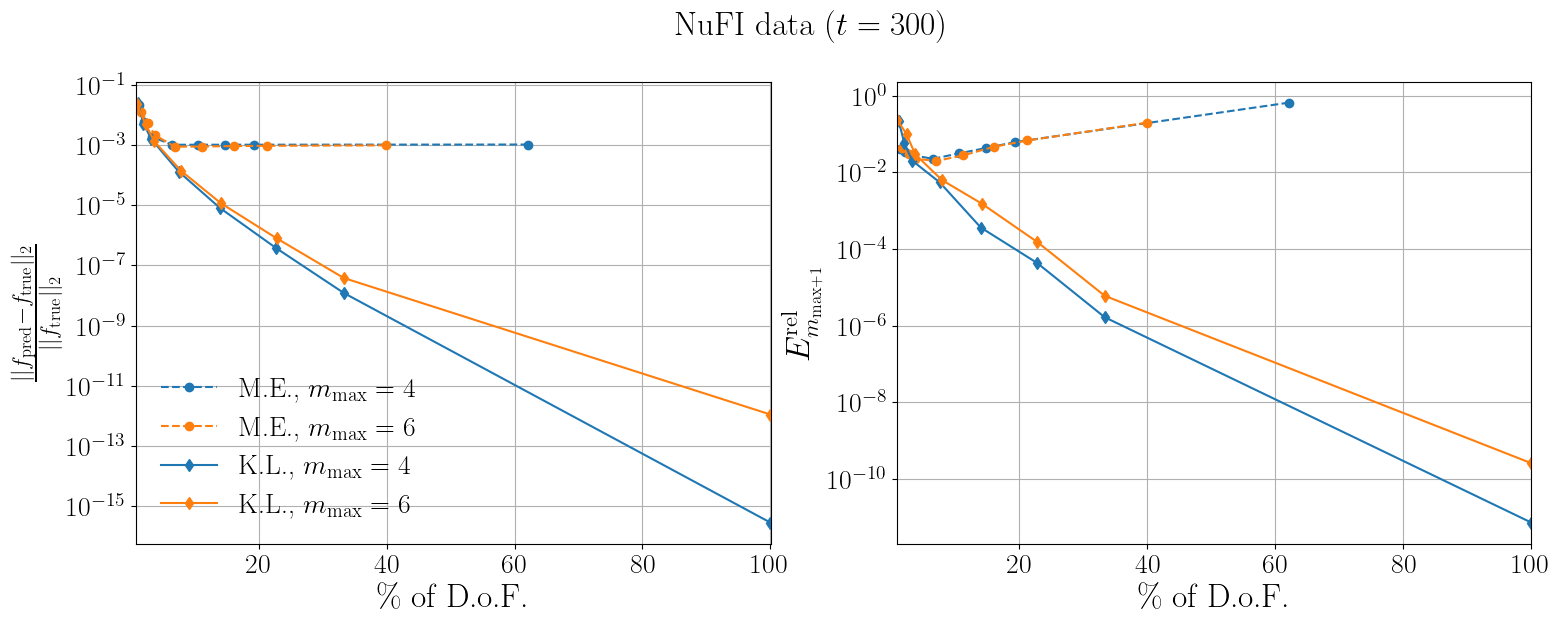

In [399]:
for t in [100, 200, 300]:
    plot_L2_and_next_errors_NuFI(path_to_output_dir, path_to_plots_dir, 128, 4, 6, t, dof_rel=True, log_1=True, log_2=True, rel_moment_err=True)

In [464]:
def plot_nufi(path_to_dir, output_path, figlabel, n_v, slice_vz_array, t_array):
    fig = plt.figure(figsize=(27,18))

    ax1 = fig.add_subplot(3,3,1)
    ax2 = fig.add_subplot(3,3,2)
    ax3 = fig.add_subplot(3,3,3)
    ax4 = fig.add_subplot(3,3,4)
    ax5 = fig.add_subplot(3,3,5)
    ax6 = fig.add_subplot(3,3,6)
    ax7 = fig.add_subplot(3,3,7)
    ax8 = fig.add_subplot(3,3,8)
    ax9 = fig.add_subplot(3,3,9)

    axes_t1 = [ax1, ax2, ax3]
    axes_t2 = [ax4, ax5, ax6]
    axes_t3 = [ax7, ax8, ax9]

    axes_wrap = [axes_t1, axes_t2, axes_t3]

    for t, axes in zip(t_array, axes_wrap):
        path_M1 = f"{path_to_dir}/KL_VDFw_NuFI_{t}_2_constraint_M_upto{4}_{n_v}.h5"
        with h5py.File(path_M1, "r") as f:
            for slice_vz, ax in zip(slice_vz_array, axes):
    
                data1 = f["vdf_hidden_truth"][slice_vz, :, :]
                vx = f["grid"][0,slice_vz,0,:]
                vy = f["grid"][1,slice_vz,:,0]
    
                X, Y = np.meshgrid(vx, vy)
                
                ax.pcolormesh(X, Y, data1, cmap='viridis')

        axes[0].set_ylabel("$v_{y}$" + f" $(t={t})$", fontsize=label_size)

    
        # ax1.set_title("Ground truth", fontsize=legend_size)
        
    for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]:
        ax.set_aspect('equal')
        ax.tick_params(axis='both', labelsize=tick_size)

    for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
        ax.set_xticklabels([])
        
    for ax in [ax2, ax3, ax5, ax6, ax8, ax9]:
        ax.set_yticklabels([])
    
    for ax in [ax7, ax8, ax9]:
        ax.set_xlabel("$v_{x}$", fontsize=label_size)

    for ax, k in zip(axes_t1, slice_vz_array):
        ax.set_title(f"$k={k}$", fontsize=legend_size)
    plt.subplots_adjust(wspace=-0.5, hspace=0.15)
    # Add colorbar
    # cbar = plt.colorbar(pc2, ax=[ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9], orientation='vertical', fraction=0.02, pad=0.08)
    # cbar.ax.tick_params(labelsize=tick_size)  # Set the font size for the tick labels
    # cbar.set_label('VDF', fontsize=label_size)  # Set the font size for the colorbar label

    fig.suptitle(figlabel, y=0.92, fontsize=label_size)
    fig.savefig(f"{output_path}/NuFI_all.png", bbox_inches="tight", dpi=300)

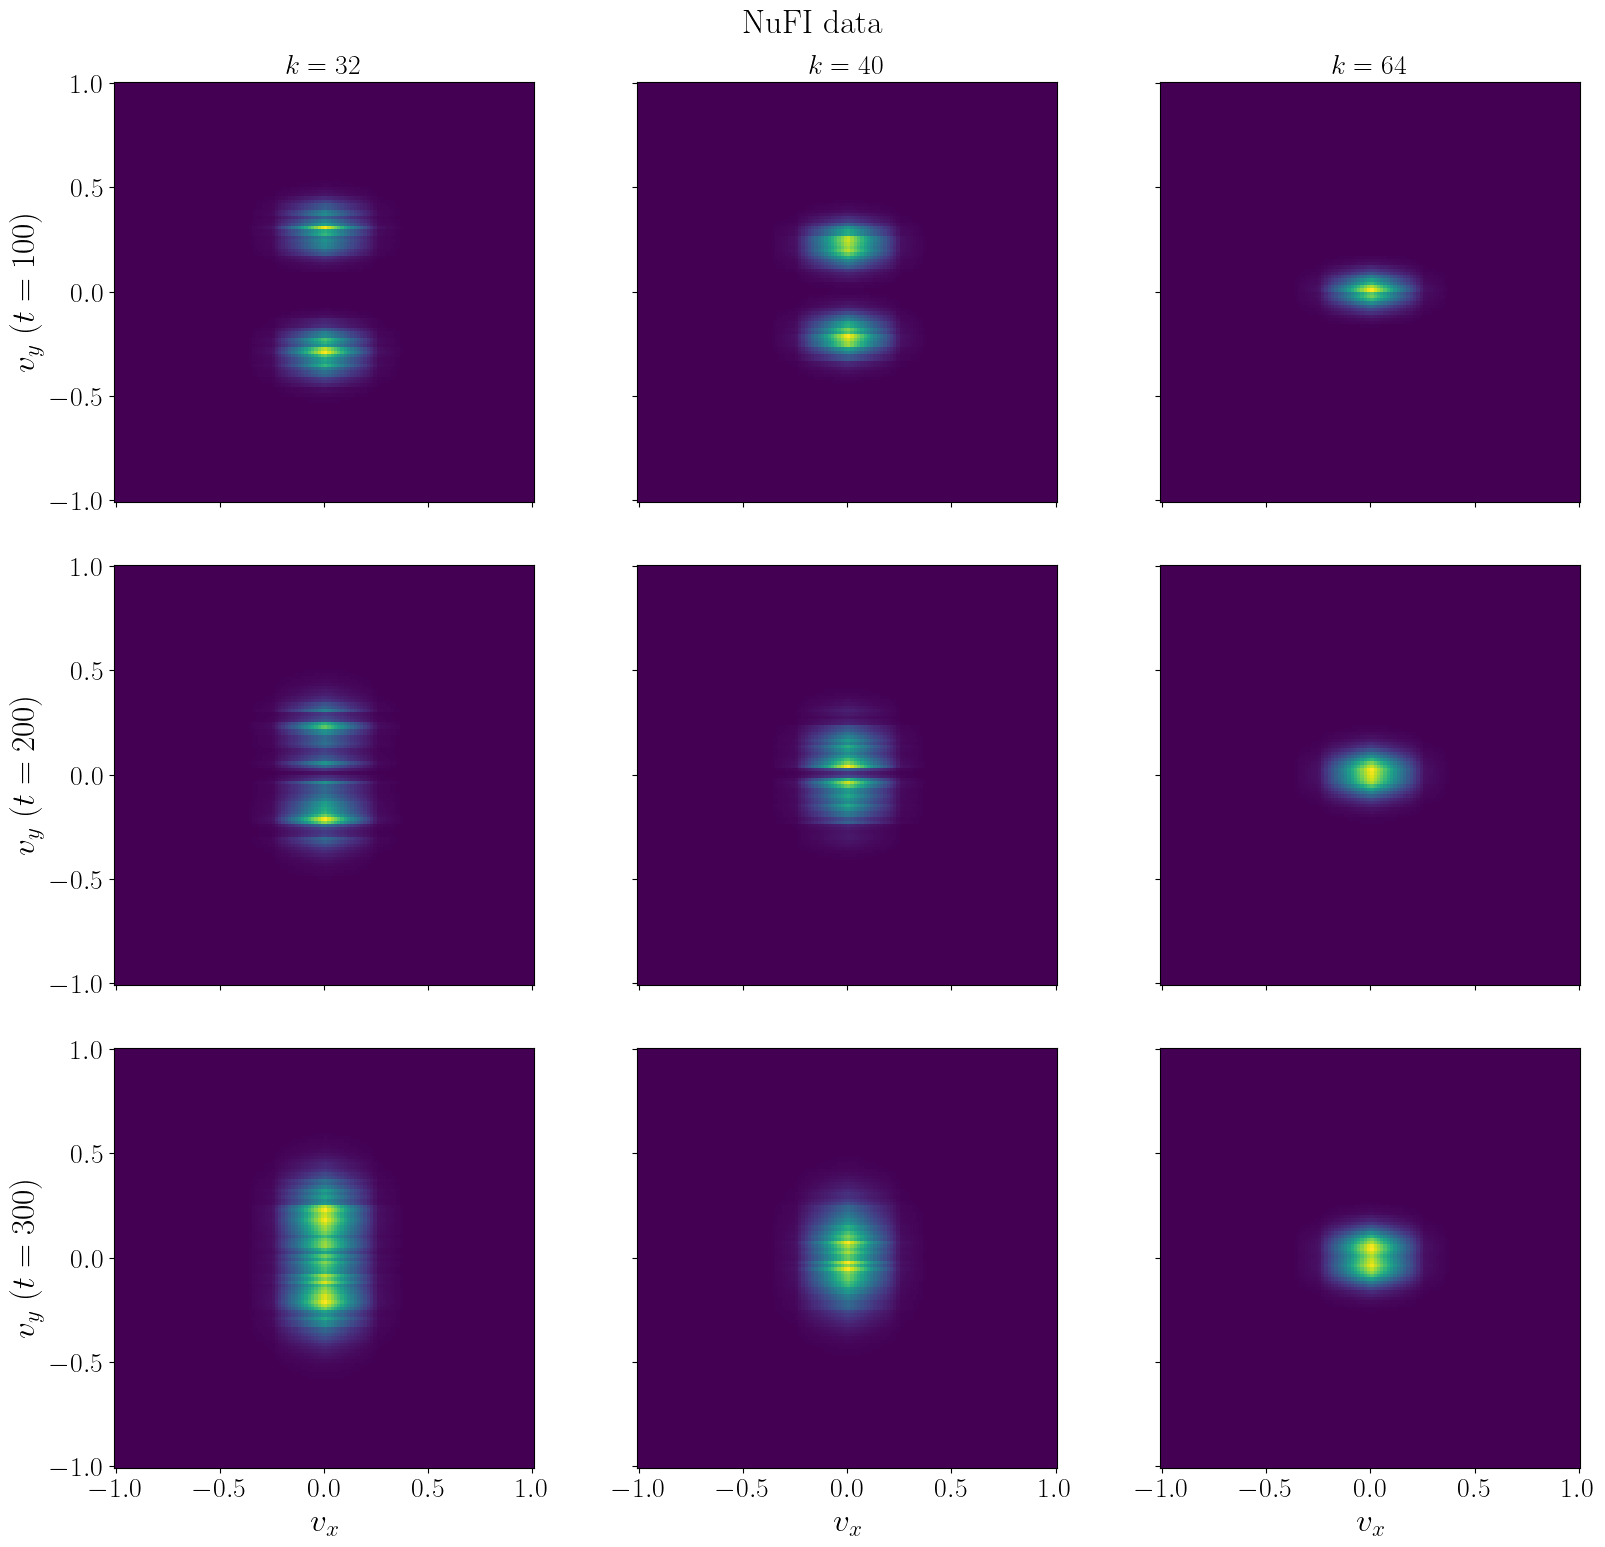

In [465]:
plot_nufi(path_to_output_dir, path_to_plots_dir, "NuFI data", 128, [32, 40, 64], [100, 200, 300])